# Predicción — Nuevos Clientes v3
Segmentación por umbrales naturales de la distribución de probabilidades.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib, os, warnings
warnings.filterwarnings("ignore")

os.chdir(r"C:\Users\alvar\OneDrive\Escritorio\Ingeniería Matemática\3º de ing Matemática\Inteligencia Artificial\Churn\RESOLUCIÓN")

modelo_final = joblib.load("modelo_churn.pkl")
cols_train   = pd.read_csv("cols_train.csv").squeeze().tolist()

print(f"✅ Modelo cargado: modelo_churn.pkl")
print(f"✅ Features de referencia: {len(cols_train)}")


✅ Modelo cargado: modelo_churn.pkl
✅ Features de referencia: 72


In [2]:
# ── 2. Cargar nuevos clientes ─────────────────────────────────────────────────
df_new = pd.read_csv("nuevos_clientes.csv")
df_new.columns = df_new.columns.str.strip()

customer_ids = df_new["Customer_ID"].copy()

if "Lead_compra_1" in df_new.columns and "Fue_Lead" not in df_new.columns:
    df_new = df_new.rename(columns={"Lead_compra_1": "Fue_Lead"})
    print("✅ Lead_compra_1 renombrada a Fue_Lead")

print(f"Shape nuevos clientes: {df_new.shape}")


✅ Lead_compra_1 renombrada a Fue_Lead
Shape nuevos clientes: (10000, 38)


In [3]:
# ── 3. Aplicar FE (idéntico al histórico) ────────────────────────────────────
cols_drop = [
    "Churn_400", "Customer_ID", "CODE", "Id_Producto",
    "DAYS_LAST_SERVICE", "Margen_eur_bruto", "Margen_eur", "EN_GARANTIA",
    "Revisiones", "Km_medio_por_revision", "km_ultima_revision",
    "days_since_sale",
]
cols_drop = [c for c in cols_drop if c in df_new.columns]
X_new = df_new.drop(columns=cols_drop)
print(f"3.1 Eliminadas → Shape: {X_new.shape}")

for col in ["Sales_Date", "BASE_DATE", "FIN_GARANTIA"]:
    if col in X_new.columns:
        X_new[col] = pd.to_datetime(X_new[col], errors="coerce", dayfirst=True)

X_new["BASE_DATE"] = pd.to_datetime("31/12/2024", dayfirst=True)

if "FIN_GARANTIA" in X_new.columns and "BASE_DATE" in X_new.columns:
    X_new["days_to_warranty_end"] = (X_new["FIN_GARANTIA"] - X_new["BASE_DATE"]).dt.days
if "days_to_warranty_end" in X_new.columns:
    X_new["warranty_expired"] = (X_new["days_to_warranty_end"] < 0).astype(int)

X_new = X_new.drop(columns=[c for c in ["Sales_Date","BASE_DATE","FIN_GARANTIA"] if c in X_new.columns])
print(f"3.2 Fechas → días → Shape: {X_new.shape}")

ext_garantia = (df_new["EXTENSION_GARANTIA"].str.upper().str.startswith("SI")).astype(int)
seguro_bat   = (df_new["SEGURO_BATERIA_LARGO_PLAZO"].str.upper() == "SI").astype(int)
mant_gratis  = (df_new["MANTENIMIENTO_GRATUITO"] > 0).astype(int)
X_new["compromiso_score"]   = ext_garantia + seguro_bat + mant_gratis

renta_safe = df_new["RENTA_MEDIA_ESTIMADA"].replace(0, df_new["RENTA_MEDIA_ESTIMADA"].median())
X_new["esfuerzo_financiero"] = df_new["PVP"] / renta_safe

X_new["garantia_expira_pronto"] = (
    (X_new["days_to_warranty_end"] >= 0) & (X_new["days_to_warranty_end"] < 180)
).astype(int)
X_new["es_financiado_marca"] = (
    df_new["FORMA_PAGO"].str.upper().str.contains("FINANCIERA MARCA", na=False)
).astype(int)
X_new["is_luxury_segment"] = (df_new["PVP"] > 35000).astype(int)
print(f"3.3 Nuevas features → Shape: {X_new.shape}")

X_new = X_new.drop(columns=[c for c in ["CODIGO_POSTAL","TIENDA_DESC"] if c in X_new.columns])

for col in X_new.select_dtypes(include=["int64","float64"]).columns:
    X_new[col] = X_new[col].fillna(X_new[col].median())
for col in X_new.select_dtypes(include="object").columns:
    X_new[col] = X_new[col].fillna("Unknown")

cat_cols = X_new.select_dtypes(include="object").columns.tolist()
X_new = pd.get_dummies(X_new, columns=cat_cols, drop_first=True)
print(f"3.4 OHE → Shape: {X_new.shape}")


3.1 Eliminadas → Shape: (10000, 29)
3.2 Fechas → días → Shape: (10000, 28)
3.3 Nuevas features → Shape: (10000, 33)
3.4 OHE → Shape: (10000, 71)


In [4]:
# ── 4. Alinear columnas ───────────────────────────────────────────────────────
for col in [c for c in cols_train if c not in X_new.columns]:
    X_new[col] = 0
X_new = X_new[cols_train]

print(f"Shape alineado: {X_new.shape} | Train: {len(cols_train)}")
print(f"{'✅ OK' if X_new.shape[1] == len(cols_train) else '❌ ERROR'}")


Shape alineado: (10000, 72) | Train: 72
✅ OK


In [5]:
# ── 5. Predicción ─────────────────────────────────────────────────────────────
y_proba_new = modelo_final.predict_proba(X_new)[:, 1]

media  = y_proba_new.mean()
std    = y_proba_new.std()

print(f"Total clientes: {len(y_proba_new)}")
print(f"\nDistribución de probabilidades:")
print(f"  Mínima:    {y_proba_new.min():.4f}")
print(f"  Media:     {media:.4f}")
print(f"  Std:       {std:.4f}")
print(f"  Mediana:   {np.median(y_proba_new):.4f}")
print(f"  Máxima:    {y_proba_new.max():.4f}")
print(f"  Media + 1std: {media + std:.4f}")
print(f"  Media + 2std: {media + 2*std:.4f}")


Total clientes: 10000

Distribución de probabilidades:
  Mínima:    0.0001
  Media:     0.0007
  Std:       0.0012
  Mediana:   0.0006
  Máxima:    0.0872
  Media + 1std: 0.0019
  Media + 2std: 0.0031


In [6]:
# ── 6. Segmentación por umbrales naturales ────────────────────────────────────
#
# En vez de forzar grupos iguales por percentiles,
# usamos la distribución real de probabilidades para definir umbrales:
#
#   Alto  → prob > media + 1 desviación típica
#   Medio → prob entre media y media + 1 desviación típica
#   Bajo  → prob < media
#
# Esto refleja fielmente que la mayoría de clientes nuevos tienen riesgo bajo
# (lógico al no tener historial de taller) y solo unos pocos tienen
# un perfil realmente preocupante.

umbral_alto  = media + 0.5*std
umbral_medio = media

def segmentar(prob):
    if prob >= umbral_alto:  return "🔴 Alto"
    elif prob >= umbral_medio: return "🟡 Medio"
    else:                    return "🟢 Bajo"

df_resultado = pd.DataFrame({
    "Customer_ID":     customer_ids.values,
    "prob_churn":      y_proba_new.round(4),
    "segmento_riesgo": [segmentar(p) for p in y_proba_new]
}).sort_values("prob_churn", ascending=False).reset_index(drop=True)

print(f"Umbrales → Alto: prob >= {umbral_alto:.4f} | Medio: prob >= {umbral_medio:.4f}")
print(f"\nDistribución por segmento:")
for seg in ["🔴 Alto","🟡 Medio","🟢 Bajo"]:
    n   = (df_resultado["segmento_riesgo"] == seg).sum()
    pct = n / len(df_resultado) * 100
    print(f"  {seg:<15} {n:>6} clientes ({pct:.1f}%)")


Umbrales → Alto: prob >= 0.0013 | Medio: prob >= 0.0007

Distribución por segmento:
  🔴 Alto             433 clientes (4.3%)
  🟡 Medio           4352 clientes (43.5%)
  🟢 Bajo            5215 clientes (52.1%)


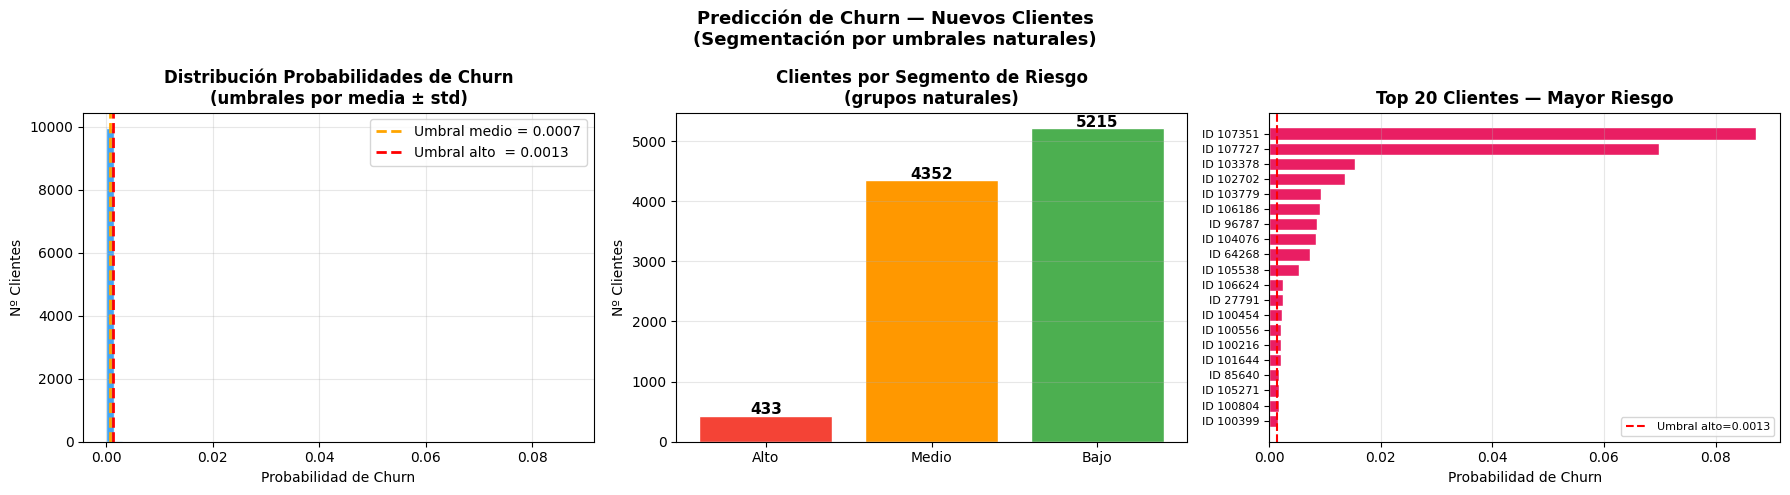

In [7]:
# ── 7. Visualizaciones ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribución de probabilidades con umbrales reales
axes[0].hist(y_proba_new, bins=60, color="#2196F3", edgecolor="white", alpha=0.85)
axes[0].axvline(umbral_medio, color="orange", linestyle="--", linewidth=2,
                label=f"Umbral medio = {umbral_medio:.4f}")
axes[0].axvline(umbral_alto,  color="red",    linestyle="--", linewidth=2,
                label=f"Umbral alto  = {umbral_alto:.4f}")
axes[0].set_title("Distribución Probabilidades de Churn\n(umbrales por media ± std)", fontweight="bold")
axes[0].set_xlabel("Probabilidad de Churn")
axes[0].set_ylabel("Nº Clientes")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Clientes por segmento (grupos desiguales — refleja la realidad)
segs   = ["🔴 Alto","🟡 Medio","🟢 Bajo"]
counts = [(df_resultado["segmento_riesgo"]==s).sum() for s in segs]
bars   = axes[1].bar(["Alto","Medio","Bajo"], counts,
                     color=["#F44336","#FF9800","#4CAF50"], edgecolor="white")
for bar, val in zip(bars, counts):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                 str(val), ha="center", fontweight="bold", fontsize=11)
axes[1].set_title("Clientes por Segmento de Riesgo\n(grupos naturales)", fontweight="bold")
axes[1].set_ylabel("Nº Clientes")
axes[1].grid(axis="y", alpha=0.3)

# Top 20
top20 = df_resultado.head(20)
axes[2].barh(range(20), top20["prob_churn"].values[::-1], color="#E91E63", edgecolor="white")
axes[2].set_yticks(range(20))
axes[2].set_yticklabels([f"ID {c}" for c in top20["Customer_ID"].values[::-1]], fontsize=8)
axes[2].axvline(umbral_alto, color="red", linestyle="--", linewidth=1.5,
                label=f"Umbral alto={umbral_alto:.4f}")
axes[2].set_title("Top 20 Clientes — Mayor Riesgo", fontweight="bold")
axes[2].set_xlabel("Probabilidad de Churn")
axes[2].legend(fontsize=8)
axes[2].grid(axis="x", alpha=0.3)

plt.suptitle("Predicción de Churn — Nuevos Clientes\n(Segmentación por umbrales naturales)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("prediccion_nuevos_clientes.png", dpi=150, bbox_inches="tight")
plt.show()


In [8]:
# ── 8. Exportar ───────────────────────────────────────────────────────────────
df_resultado.to_csv("prediccion_todos_clientes.csv", index=False)
df_resultado[df_resultado["segmento_riesgo"] != "🟢 Bajo"].to_csv(
    "clientes_accion_retencion.csv", index=False)

n_accion = (df_resultado["segmento_riesgo"] != "🟢 Bajo").sum()
print(f"✅ prediccion_todos_clientes.csv  → {len(df_resultado)} clientes")
print(f"✅ clientes_accion_retencion.csv  → {n_accion} clientes (Alto + Medio)")
print(f"\nTop 10 clientes a retener:")
print(df_resultado.head(10).to_string(index=False))


✅ prediccion_todos_clientes.csv  → 10000 clientes
✅ clientes_accion_retencion.csv  → 4785 clientes (Alto + Medio)

Top 10 clientes a retener:
 Customer_ID  prob_churn segmento_riesgo
      107351      0.0872          🔴 Alto
      107727      0.0699          🔴 Alto
      103378      0.0153          🔴 Alto
      102702      0.0135          🔴 Alto
      103779      0.0092          🔴 Alto
      106186      0.0090          🔴 Alto
       96787      0.0086          🔴 Alto
      104076      0.0083          🔴 Alto
       64268      0.0072          🔴 Alto
      105538      0.0054          🔴 Alto
